# Real LLM Next Token Probabilities

This notebook demonstrates how language models convert raw scores (logits) into probabilities using the Softmax function.

It explores:
- Logits
- Softmax
- Temperature
- Random sampling

The purpose is to understand the mechanics behind next-token prediction before examining a real language model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Hello, Tiny LLM!")

Hello, Tiny LLM!


In [2]:
vocab = [
    "mat",
    "chair",
    "table",
    "moon",
    "banana",
    "roof",
    "floor",
    "grass",
    "bed",
    "sofa",
    "dog",
    "car",
    "tree",
    "computer",
    "river"
]

print(vocab)
print(f"\nVocabulary size: {len(vocab)}")

['mat', 'chair', 'table', 'moon', 'banana', 'roof', 'floor', 'grass', 'bed', 'sofa', 'dog', 'car', 'tree', 'computer', 'river']

Vocabulary size: 15


In [3]:
logits = np.array([
    4.2,    # mat
    1.5,    # chair
    1.3,    # table
    0.2,    # moon
   -0.5,    # banana
    3.2,    # roof
    2.4,    # floor
    1.2,    # grass
    2.0,    # bed
    1.4,    # sofa
    0.8,    # dog
   -0.2,    # car
    3.6,    # tree
   -1.0,    # computer
   -0.8     # river
])

for word, score in zip(vocab, logits):
    print(f"{word:10} {score:5.1f}")

mat          4.2
chair        1.5
table        1.3
moon         0.2
banana      -0.5
roof         3.2
floor        2.4
grass        1.2
bed          2.0
sofa         1.4
dog          0.8
car         -0.2
tree         3.6
computer    -1.0
river       -0.8


In [4]:
def softmax(logits):

    # Prevent very large numbers
    shifted = logits - np.max(logits)

    # Exponentiate every score
    exp_values = np.exp(shifted)

    # Normalize so everything adds to 1
    probabilities = exp_values / np.sum(exp_values)

    return probabilities

In [5]:
probs = softmax(logits)

for word, p in zip(vocab, probs):
    print(f"{word:10} {p:.4f}")

print(f"\nTotal probability = {probs.sum():.4f}")

mat        0.3983
chair      0.0268
table      0.0219
moon       0.0073
banana     0.0036
roof       0.1465
floor      0.0658
grass      0.0198
bed        0.0441
sofa       0.0242
dog        0.0133
car        0.0049
tree       0.2186
computer   0.0022
river      0.0027

Total probability = 1.0000


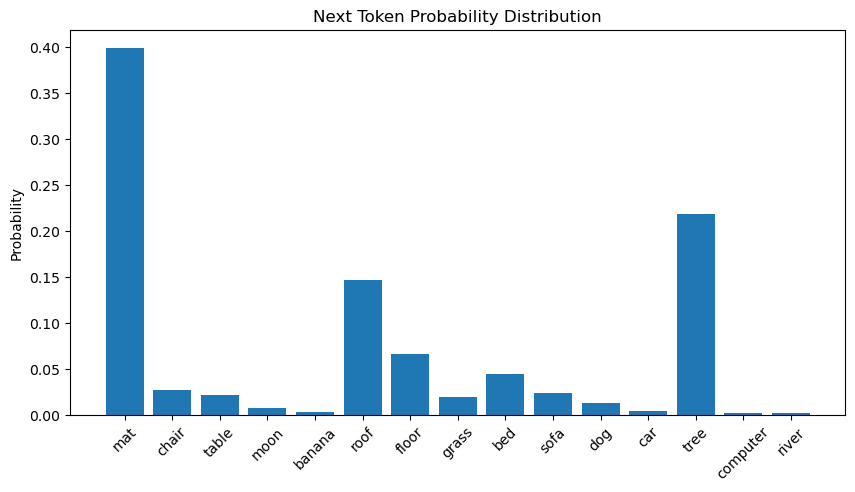

In [6]:
plt.figure(figsize=(10,5))

plt.bar(vocab, probs)

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.title("Next Token Probability Distribution")

plt.show()

## Effect of Temperature

Temperature controls how confident or random the model's next-token predictions are.

- **Lower temperatures** make the probability distribution sharper, causing the model to favour the most likely tokens.
- **Higher temperatures** flatten the probability distribution, giving less likely tokens a greater chance of being selected.

The following examples compare the effect of different temperature values on the same set of logits.

In [7]:
def softmax(logits, temperature=1.0):

    adjusted = logits / temperature

    shifted = adjusted - np.max(adjusted)

    exp_values = np.exp(shifted)

    probabilities = exp_values / np.sum(exp_values)

    return probabilities

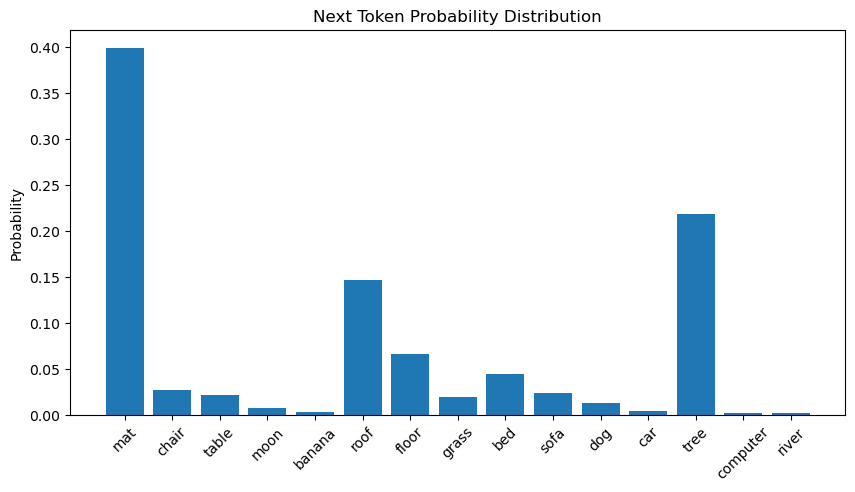

In [8]:
plt.figure(figsize=(10,5))

plt.bar(vocab, probs)

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.title("Next Token Probability Distribution")

plt.show()

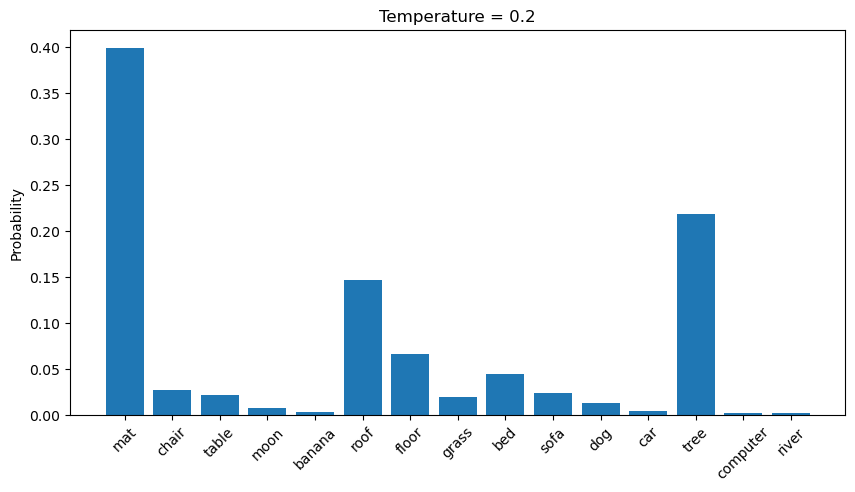

In [9]:
plt.figure(figsize=(10,5))

plt.bar(vocab, probs)

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.title("Temperature = 0.2")

plt.show()

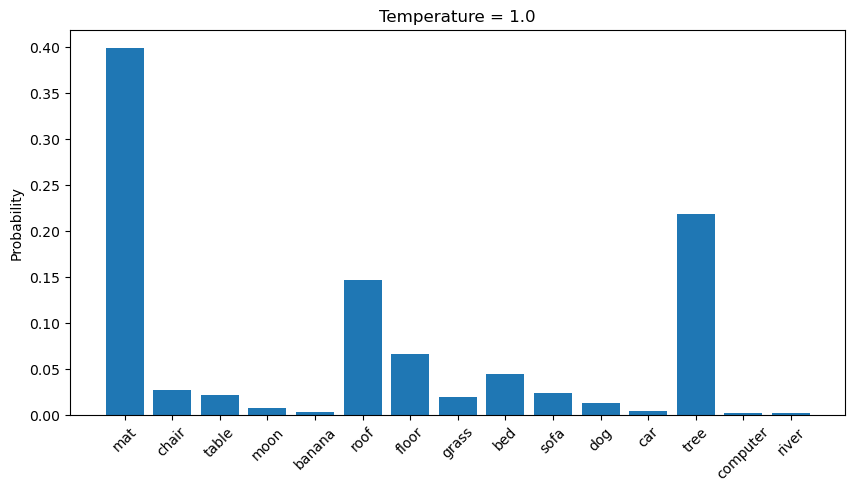

In [10]:
plt.figure(figsize=(10,5))

plt.bar(vocab, probs)

plt.xticks(rotation=45)

plt.ylabel("Probability")

plt.title("Temperature = 1.0")

plt.show()

In [11]:
probs = softmax(logits, temperature=2.0)

In [12]:
def plot_distribution(probs, temperature):

    plt.figure(figsize=(10,5))

    plt.bar(vocab, probs)

    plt.xticks(rotation=45)

    plt.ylabel("Probability")

    plt.title(f"Temperature = {temperature}")

    plt.show()

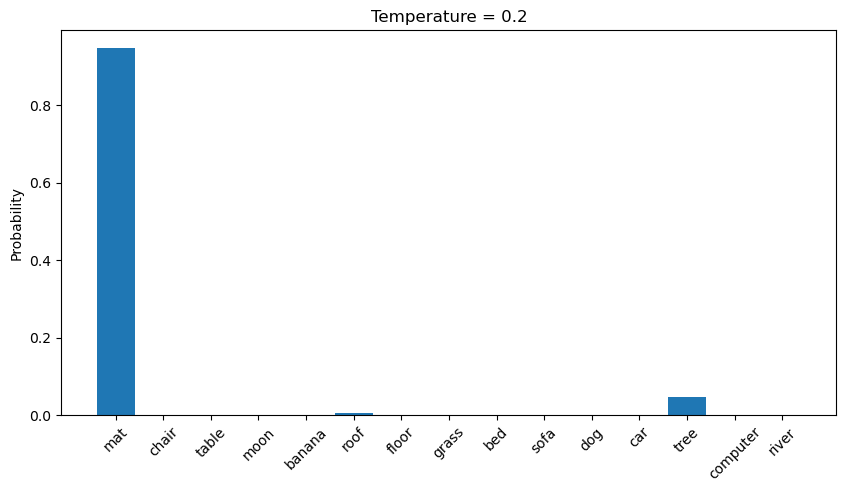

In [13]:
probs = softmax(logits, temperature=0.2)
plot_distribution(probs, 0.2)

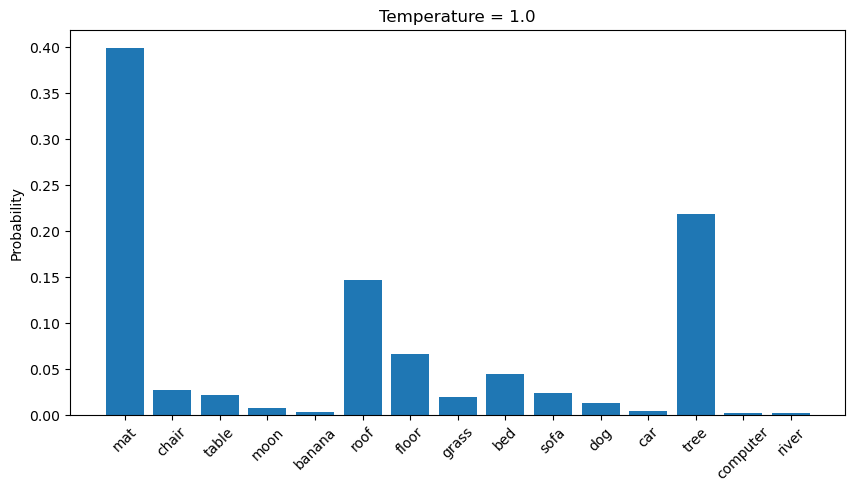

In [14]:
probs = softmax(logits, temperature=1.0)
plot_distribution(probs, 1.0)

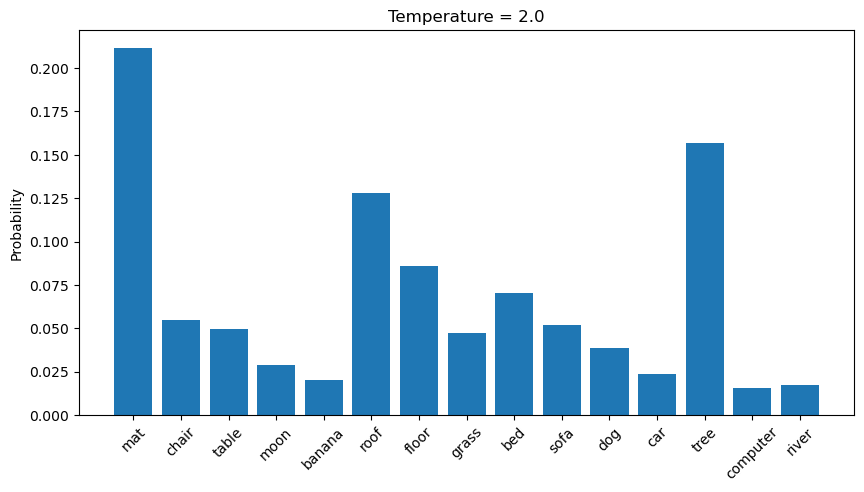

In [15]:
probs = softmax(logits, temperature=2.0)
plot_distribution(probs, 2.0)

In [16]:
next_token = np.random.choice(vocab, p=probs)
print(next_token)

mat


In [17]:
next_token = np.random.choice(vocab, p=probs)
print(next_token)

mat


## Random Sampling

After converting logits into probabilities, a language model does not always choose the most probable token.

Instead, it samples from the probability distribution. Tokens with higher probabilities are more likely to be selected, but less likely tokens can still be chosen—especially at higher temperatures.

The following example demonstrates a single random sample from the probability distribution.

In [18]:
next_token = np.random.choice(vocab, p=probs)

print("Sampled token:", next_token)

Sampled token: tree
